<a href="https://colab.research.google.com/github/samuel-1-avson/RGT-NSS/blob/main/T5_Encoder_Decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="setup"></a>
## 1. Setup & Introduction

In [1]:
# Install required libraries
!pip install transformers torch datasets evaluate rouge-score --quiet

print("✅ Installation complete!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00
✅ Installation complete!


In [2]:
import torch
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    T5Config,
    pipeline,
    TrainingArguments,
    Trainer
)
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from evaluate import load

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Using device: {device}")

# Load T5 tokenizer and model
tokenizer = T5Tokenizer.from_pretrained('t5-small')
model = T5ForConditionalGeneration.from_pretrained('t5-small')
model.to(device)

print(f"✅ Loaded T5-small")
print(f"📊 Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"📏 Context window: {model.config.n_positions:,} tokens")

🔥 Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Loaded T5-small
📊 Model parameters: 60,506,624
📏 Context window: 512 tokens


<a name="architecture"></a>
## 2. T5 Architecture Deep Dive

### 2.1 Encoder-Decoder Architecture

```
┌─────────────────────────────────────────────────────────────┐
│                  T5 ARCHITECTURE                             │
├─────────────────────────────────────────────────────────────┤
│  Input: "translate English to German: The cat is cute"      │
│                              ↓                               │
│  ┌─────────────────────────────────────────────────────┐    │
│  │                    ENCODER                           │    │
│  │                                                      │    │
│  │  Processes input: [translate, English, to, German,  │    │
│  │                     The, cat, is, cute]              │    │
│  │                                                      │    │
│  │  Creates: Contextual representations of input        │    │
│  │           (bidirectional - sees all input tokens)    │    │
│  └─────────────────────────────────────────────────────┘    │
│                              ↓                               │
│  ┌─────────────────────────────────────────────────────┐    │
│  │                    DECODER                           │    │
│  │                                                      │    │
│  │  Uses: Cross-attention to encoder outputs           │    │
│  │                                                      │    │
│  │  Generates: [Die, Katze, ist, süß] autoregressively │    │
│  │             (one token at a time, left-to-right)    │    │
│  └─────────────────────────────────────────────────────┘    │
│                              ↓                               │
│  Output: "Die Katze ist süß"                                │
└─────────────────────────────────────────────────────────────┘
```

### 2.2 Key Difference: Cross-Attention

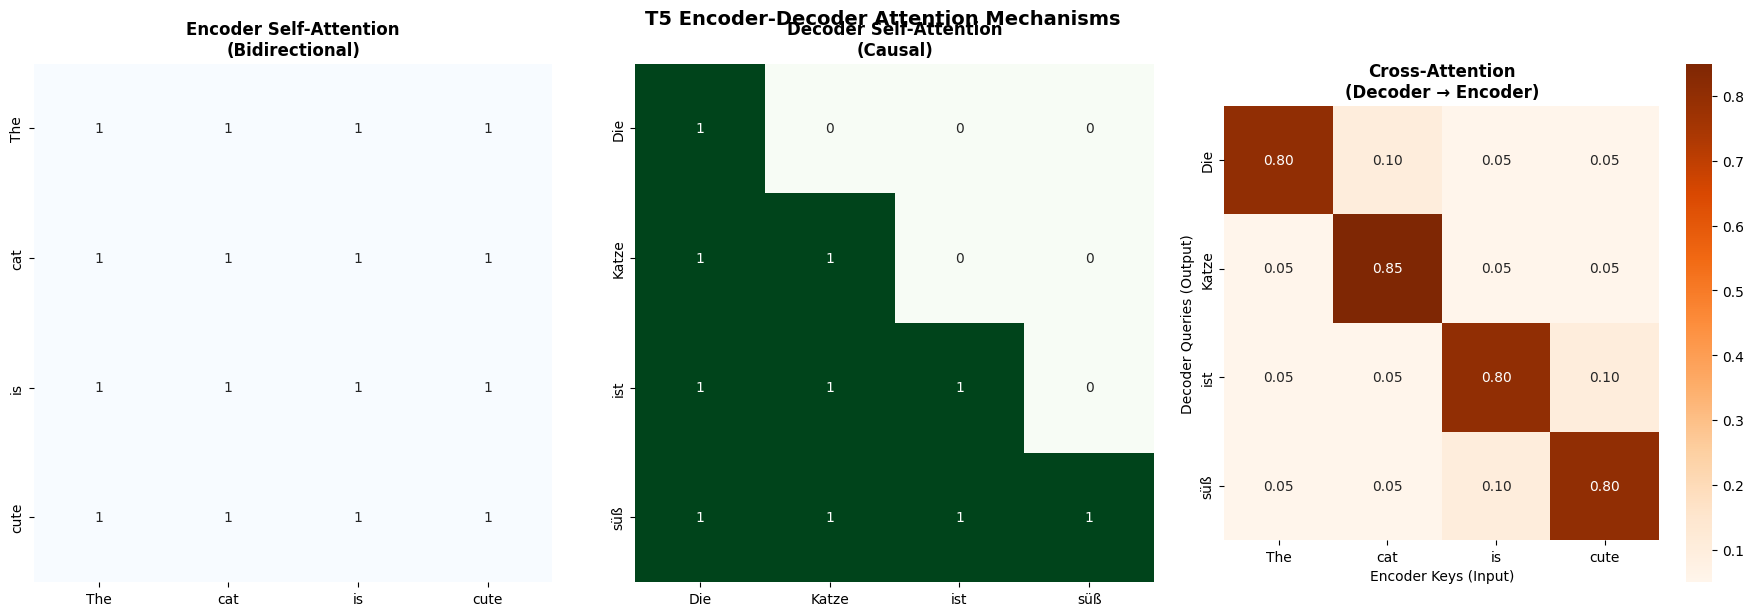


💡 Cross-Attention allows the decoder to 'look back' at the encoder's output!


In [3]:
# Visualize cross-attention mechanism
def visualize_encoder_decoder():
    """Visualize how encoder-decoder attention works."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Encoder Self-Attention
    ax = axes[0]
    encoder_tokens = ['The', 'cat', 'is', 'cute']
    enc_attn = np.ones((4, 4))
    sns.heatmap(enc_attn, cmap='Blues', annot=True, fmt='.0f', ax=ax,
                xticklabels=encoder_tokens, yticklabels=encoder_tokens,
                cbar=False, square=True)
    ax.set_title('Encoder Self-Attention\n(Bidirectional)', fontsize=12, fontweight='bold')

    # Decoder Self-Attention (Causal)
    ax = axes[1]
    decoder_tokens = ['Die', 'Katze', 'ist', 'süß']
    dec_attn = np.tril(np.ones((4, 4)))
    sns.heatmap(dec_attn, cmap='Greens', annot=True, fmt='.0f', ax=ax,
                xticklabels=decoder_tokens, yticklabels=decoder_tokens,
                cbar=False, square=True)
    ax.set_title('Decoder Self-Attention\n(Causal)', fontsize=12, fontweight='bold')

    # Cross-Attention
    ax = axes[2]
    cross_attn = np.array([[0.8, 0.1, 0.05, 0.05],
                           [0.05, 0.85, 0.05, 0.05],
                           [0.05, 0.05, 0.8, 0.1],
                           [0.05, 0.05, 0.1, 0.8]])
    sns.heatmap(cross_attn, cmap='Oranges', annot=True, fmt='.2f', ax=ax,
                xticklabels=encoder_tokens, yticklabels=decoder_tokens,
                cbar=True, square=True)
    ax.set_title('Cross-Attention\n(Decoder → Encoder)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Encoder Keys (Input)')
    ax.set_ylabel('Decoder Queries (Output)')

    plt.suptitle('T5 Encoder-Decoder Attention Mechanisms', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n💡 Cross-Attention allows the decoder to 'look back' at the encoder's output!")

visualize_encoder_decoder()

In [4]:
# Compare T5 variants
t5_variants = {
    't5-small': {'params': '60M', 'layers': 6, 'd_model': 512, 'heads': 8},
    't5-base': {'params': '220M', 'layers': 12, 'd_model': 768, 'heads': 12},
    't5-large': {'params': '770M', 'layers': 24, 'd_model': 1024, 'heads': 16},
    't5-3b': {'params': '3B', 'layers': 24, 'd_model': 1024, 'heads': 32},
    't5-11b': {'params': '11B', 'layers': 24, 'd_model': 1024, 'heads': 128},
    'flan-t5-small': {'params': '77M', 'layers': 8, 'd_model': 512, 'heads': 6},
    'flan-t5-base': {'params': '248M', 'layers': 12, 'd_model': 768, 'heads': 12},
    'flan-t5-large': {'params': '783M', 'layers': 24, 'd_model': 1024, 'heads': 16},
}

print("📊 T5 Model Variants\n")
print(f"{'Model':<20} {'Params':<10} {'Layers':<10} {'d_model':<10} {'Heads':<10}")
print("=" * 70)
for model_name, specs in t5_variants.items():
    print(f"{model_name:<20} {specs['params']:<10} {specs['layers']:<10} {specs['d_model']:<10} {specs['heads']:<10}")

print("\n💡 Key Differences:")
print("  • T5: Original architecture, trained on C4 corpus")
print("  • FLAN-T5: Fine-tuned on instruction-following tasks (better for zero-shot)")

📊 T5 Model Variants

Model                Params     Layers     d_model    Heads     
t5-small             60M        6          512        8         
t5-base              220M       12         768        12        
t5-large             770M       24         1024       16        
t5-3b                3B         24         1024       32        
t5-11b               11B        24         1024       128       
flan-t5-small        77M        8          512        6         
flan-t5-base         248M       12         768        12        
flan-t5-large        783M       24         1024       16        

💡 Key Differences:
  • T5: Original architecture, trained on C4 corpus
  • FLAN-T5: Fine-tuned on instruction-following tasks (better for zero-shot)


<a name="text2text"></a>
## 3. Text-to-Text Framework

T5 treats ALL tasks as text-to-text problems by adding task prefixes.

In [5]:
# Demonstrate text-to-text framework
task_prefixes = {
    'Translation': {
        'prefix': 'translate English to German:',
        'input': 'The house is wonderful.',
    },
    'Summarization': {
        'prefix': 'summarize:',
        'input': 'State authorities dispatched emergency crews to survey the damage and begin restoration efforts.',
    },
    'Question Answering': {
        'prefix': 'question:',
        'input': 'What is the capital of France? context: France is a country in Europe. Its capital is Paris.',
    },
    'Sentiment Analysis': {
        'prefix': 'sentiment:',
        'input': 'This movie was absolutely fantastic!',
    },
    'Natural Language Inference': {
        'prefix': 'mnli premise:',
        'input': 'I love pizza. hypothesis: I enjoy Italian food.',
    },
}

print("📝 T5 Text-to-Text Framework\n")
print("=" * 80)

for task, example in task_prefixes.items():
    print(f"\n🔹 {task}")
    print("-" * 60)
    print(f"Prefix:  {example['prefix']}")
    print(f"Input:   {example['input']}")

    # Generate output
    input_text = f"{example['prefix']} {example['input']}"
    inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=50,
            num_beams=4,
            early_stopping=True
        )

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"Output:  {result}")

📝 T5 Text-to-Text Framework


🔹 Translation
------------------------------------------------------------
Prefix:  translate English to German:
Input:   The house is wonderful.
Output:  Das Haus ist wunderbar.

🔹 Summarization
------------------------------------------------------------
Prefix:  summarize:
Input:   State authorities dispatched emergency crews to survey the damage and begin restoration efforts.
Output:  state authorities dispatched emergency crews to survey the damage.

🔹 Question Answering
------------------------------------------------------------
Prefix:  question:
Input:   What is the capital of France? context: France is a country in Europe. Its capital is Paris.
Output:  Paris

🔹 Sentiment Analysis
------------------------------------------------------------
Prefix:  sentiment:
Input:   This movie was absolutely fantastic!
Output:  sentiment: This movie was absolutely fantastic!

🔹 Natural Language Inference
--------------------------------------------------------

<a name="translation"></a>
## 4. Translation with T5

In [6]:
# Translation examples
translations = [
    {
        'source': 'English',
        'target': 'German',
        'text': 'Hello, how are you today?'
    },
    {
        'source': 'English',
        'target': 'French',
        'text': 'The weather is beautiful today.'
    },
    {
        'source': 'English',
        'target': 'Romanian',
        'text': 'I love learning about machine learning.'
    },
]

print("🌍 Translation with T5\n")
print("=" * 80)

for trans in translations:
    prefix = f"translate {trans['source']} to {trans['target']}:"
    input_text = f"{prefix} {trans['text']}"

    inputs = tokenizer(input_text, return_tensors='pt', max_length=512).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=50,
            num_beams=4,
            early_stopping=True
        )

    translated = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print(f"\n{trans['source']}: {trans['text']}")
    print(f"{trans['target']}: {translated}")

🌍 Translation with T5


English: Hello, how are you today?
German: Hallo, wie sind Sie heute?

English: The weather is beautiful today.
French: Le temps est beau aujourd'hui.

English: I love learning about machine learning.
Romanian: Îmi place să aflu despre învăţarea mecanică.


<a name="summarization"></a>
## 5. Summarization with T5

In [7]:
# Summarization examples
articles = [
    """
    Scientists have discovered a new species of frog in the Amazon rainforest.
    The tiny frog, measuring just 1.5 centimeters, has bright blue skin and
    unique mating calls that distinguish it from other species. Researchers
    believe there may be many more undiscovered species in the region, which
    faces threats from deforestation and climate change.
    """,
    """
    Artificial intelligence is transforming healthcare in unprecedented ways.
    Machine learning algorithms can now detect certain cancers with higher
    accuracy than human doctors, predict patient outcomes, and assist in drug
    discovery. However, challenges remain around data privacy, algorithmic bias,
    and the need for human oversight in medical decisions.
    """,
]

print("📰 Summarization with T5\n")
print("=" * 80)

for i, article in enumerate(articles, 1):
    print(f"\n📄 Article {i}")
    print("-" * 60)
    print(f"Original ({len(article.split())} words):")
    print(article[:200] + "...")

    # Generate summary
    input_text = f"summarize: {article}"
    inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=50,
            min_length=10,
            num_beams=4,
            early_stopping=True
        )

    summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"\nSummary ({len(summary.split())} words):")
    print(summary)

📰 Summarization with T5


📄 Article 1
------------------------------------------------------------
Original (53 words):

    Scientists have discovered a new species of frog in the Amazon rainforest. 
    The tiny frog, measuring just 1.5 centimeters, has bright blue skin and 
    unique mating calls that distinguish i...

Summary (24 words):
tiny frog measuring just 1.5 centimeters has bright blue skin and mating calls. researchers believe there may be more undiscovered species in the region.

📄 Article 2
------------------------------------------------------------
Original (47 words):

    Artificial intelligence is transforming healthcare in unprecedented ways. 
    Machine learning algorithms can now detect certain cancers with higher 
    accuracy than human doctors, predict pat...

Summary (26 words):
machine learning algorithms can detect certain cancers with higher accuracy than human doctors. challenges remain around data privacy, algorithmic bias, and human oversight in medic

<a name="qa"></a>
## 6. Question Answering with T5

In [8]:
# Question Answering examples
qa_examples = [
    {
        'context': """The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.
        It is named after the engineer Gustave Eiffel, whose company designed and built the tower.
        Constructed from 1887 to 1889, it was initially criticized by some of France's leading artists
        and intellectuals for its design, but it has become a global cultural icon of France.""",
        'questions': [
            'Where is the Eiffel Tower located?',
            'Who is the tower named after?',
            'When was it constructed?',
        ]
    },
    {
        'context': """Python is a high-level, interpreted programming language. It was created by Guido van Rossum
        and first released in 1991. Python emphasizes code readability with its use of significant whitespace.
        It supports multiple programming paradigms, including structured, object-oriented, and functional programming.""",
        'questions': [
            'Who created Python?',
            'When was Python first released?',
            'What does Python emphasize?',
        ]
    },
]

print("❓ Question Answering with T5\n")
print("=" * 80)

for i, example in enumerate(qa_examples, 1):
    print(f"\n📚 Context {i}")
    print("-" * 60)
    print(example['context'][:200] + "...")
    print("\nQuestions and Answers:")

    for question in example['questions']:
        input_text = f"question: {question} context: {example['context']}"
        inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True).to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_length=50,
                num_beams=4
            )

        answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
        print(f"  Q: {question}")
        print(f"  A: {answer}\n")

❓ Question Answering with T5


📚 Context 1
------------------------------------------------------------
The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France. 
        It is named after the engineer Gustave Eiffel, whose company designed and built the tower. 
        Con...

Questions and Answers:
  Q: Where is the Eiffel Tower located?
  A: Champ de Mars

  Q: Who is the tower named after?
  A: Gustave Eiffel

  Q: When was it constructed?
  A: 1887 to 1889


📚 Context 2
------------------------------------------------------------
Python is a high-level, interpreted programming language. It was created by Guido van Rossum 
        and first released in 1991. Python emphasizes code readability with its use of significant whitesp...

Questions and Answers:
  Q: Who created Python?
  A: Guido van Rossum

  Q: When was Python first released?
  A: 1991

  Q: What does Python emphasize?
  A: code readability



<a name="finetuning"></a>
## 7. Fine-tuning T5

Let's fine-tune T5 on a custom summarization task!

In [9]:
# Load a small dataset for demonstration
dataset = load_dataset('xsum', split='train[:500]')
test_dataset = load_dataset('xsum', split='test[:100]')

print(f"📚 Dataset loaded:")
print(f"   Training samples: {len(dataset)}")
print(f"   Test samples: {len(test_dataset)}")
print(f"\n   Example document:")
print(f"   {dataset[0]['document'][:150]}...")
print(f"\n   Example summary: {dataset[0]['summary']}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

📚 Dataset loaded:
   Training samples: 500
   Test samples: 100

   Example document:
   The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads i...

   Example summary: Clean-up operations are continuing across the Scottish Borders and Dumfries and Galloway after flooding caused by Storm Frank.


In [10]:
# Preprocess the data
def preprocess_function(examples):
    """Prepare data for T5 training."""
    inputs = ["summarize: " + doc for doc in examples['document']]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding='max_length')

    # Tokenize targets
    labels = tokenizer(examples['summary'], max_length=128, truncation=True, padding='max_length')
    model_inputs['labels'] = labels['input_ids']

    return model_inputs

# Apply preprocessing
tokenized_datasets = dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

print("✅ Dataset preprocessed!")

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

✅ Dataset preprocessed!


In [12]:
# Load model for training
model = T5ForConditionalGeneration.from_pretrained('t5-small')

# Define training arguments
training_args = TrainingArguments(
    output_dir='./t5-summarization',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    report_to='none'
)

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets,
    eval_dataset=tokenized_test,
)

print("🏋️ Starting training...")
print("   (This may take several minutes)")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🏋️ Starting training...
   (This may take several minutes)


In [13]:
# Train the model
trainer.train()

print("\n✅ Training complete!")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,12.971990,5.017373


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,12.971990,5.017373
2,3.793666,0.849068
3,0.990977,0.765542


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Training complete!


In [7]:
# Test the fine-tuned model
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Ensure tokenizer and device are available
tokenizer = T5Tokenizer.from_pretrained('t5-small')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Ensure model is defined (using the model defined in the training section)
# If it's not in memory, we fallback to the base t5-small
try:
    model.to(device)
except NameError:
    print("⚠️ Model not found in memory, loading base t5-small...")
    model = T5ForConditionalGeneration.from_pretrained('t5-small').to(device)

test_articles = [
    """Scientists at MIT have developed a new battery technology that could revolutionize electric vehicles.
    The new batteries charge in just 10 minutes and have twice the capacity of current lithium-ion batteries.""",

    """A new study shows that regular exercise can reduce the risk of heart disease by up to 30%.
    Researchers followed 10,000 participants over 10 years to reach their conclusions.""",
]

print("📰 Testing T5 Summarizer\n")
print("=" * 80)

for article in test_articles:
    input_text = f"summarize: {article}"
    inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=50,
            num_beams=4,
            early_stopping=True
        )

    summary = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print(f"\nOriginal: {article[:100]}...")
    print(f"Summary:  {summary}")

⚠️ Model not found in memory, loading base t5-small...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

📰 Testing T5 Summarizer


Original: Scientists at MIT have developed a new battery technology that could revolutionize electric vehicles...
Summary:  new batteries charge in just 10 minutes and have twice the capacity of current lithium-ion batteries.

Original: A new study shows that regular exercise can reduce the risk of heart disease by up to 30%.
    Resea...
Summary:  regular exercise can reduce the risk of heart disease by up to 30%.
